In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
train_dir = "dataset/fruits/train"
test_dir = "dataset/fruits/test"

In [3]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical' #multiclass - 9fruits
)

Found 359 images belonging to 9 classes.
Found 208 images belonging to 9 classes.


In [4]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(9, activation='softmax')   # 🔥 9 classes
])

C:\Users\Shailesh Yadav\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 55s 4s/step - accuracy: 0.1031 - loss: 2.4446 - val_accuracy: 0.2981 - val_loss: 2.1366
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.2451 - loss: 2.0365 - val_accuracy: 0.3606 - val_loss: 1.7849
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.3649 - loss: 1.7039 - val_accuracy: 0.4423 - val_loss: 1.5583
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.4735 - loss: 1.4523 - val_accuracy: 0.5817 - val_loss: 1.2401
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.5404 - loss: 1.2815 - val_accuracy: 0.6154 - val_loss: 1.0099
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.5320 - loss: 1.2363 - val_accuracy: 0.6298 - val_loss: 1.0611
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.5989 - loss: 1.0544 - val_accuracy: 0.6779 - val_loss: 0.8946
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.6184 - loss: 1.0984 - val_accuracy: 0.6875 - val_loss:

In [8]:
model.save("fruits_model_9class.h5")

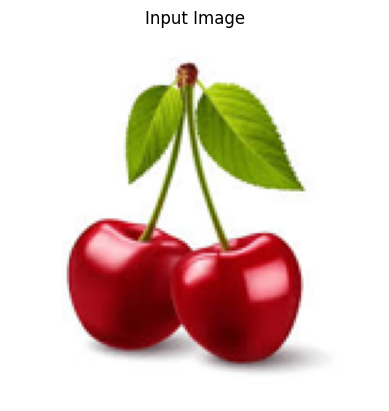

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
Predicted: cherry fruit


In [14]:
class_names = list(train_data.class_indices.keys())

def predict_image(path):
    img = Image.open(path).convert("RGB").resize((150,150))
    img = np.array(img) / 255.0
    img = img.reshape(1,150,150,3)

    plt.imshow(img[0])
    plt.title("Input Image")
    plt.axis('off')
    plt.show()

    pred = model.predict(img)
    index = np.argmax(pred)

    print(f"Predicted: {class_names[index]}")

# Example:
predict_image("ch.jpg")